In [34]:
## need to activate nm_swe environment and specify path to kernel 
# conda env create -f setup/environment.yml
# conda activate nm_swe
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rasterio as rio
import rioxarray as rxr
import matplotlib.pyplot as plt
from glob import glob
import re
import matplotlib.colors as mcolors
import contextily as cx
import matplotlib.patheffects as PathEffects

## Set date for plotting

In [33]:
## set date
date = "20250401"

## Figure 1 in UTM

### Read SNODAS data and shapefiles

In [35]:
# Read data, reproject to UTM Zone 13N
snodas = rxr.open_rasterio('../data/SNODAS/SNODAS_SWE_' + date + '.tif').sel(band=1).reset_coords('band', drop=True)
snodas_utm = snodas.rio.reproject('epsg:26913', resolution=1000, resampling = 0) # 0=nearest neighbor
huc6 = gpd.read_file('../data/Shapefiles/WBDHU6_RG/WBDHU6_RG.shp').to_crs('epsg:26913')
huc8 = gpd.read_file('../data/Shapefiles/WBDHU8_RG/WBDHU8_RG.shp').to_crs('epsg:26913')
huc8 = huc8.drop(huc8.index[72])
# Subset HUC6 for visualization, clip SWE data
#huc6_viz = huc6.loc[huc6['Name'].isin(['Rio Grande Headwaters','Upper Rio Grande','Rio Grande-Elephant Butte'])]
OSE = gpd.read_file("../data/Shapefiles/OSE_Basin_Designations/SubBasins_Dissolve.shp").to_crs('epsg:26913')

## select first 3 rows
huc6_polys = ['Rio Grande Headwaters', 'Upper Rio Grande',
       'Rio Grande-Elephant Butte']
huc6 = huc6[huc6['Name'].isin(huc6_polys)]
#HUC6 = HUC6.head(3)
huc6['Name'].unique()

## select OSE polygons of interest
OSE['SubBasin'].unique()
OSE = OSE.loc[OSE['SubBasin'] != 'San Juan River Basin']
OSE['SubBasin'].unique()

OSE = OSE.replace({'SubBasin' : {'JemezRiver Basin' : 'Jemez', 
                             'Rio Chama River Basin' : 'Rio Chama', 
                             'Sangre De Cristo Mountain Range Basins' : 'Sangre de Cristo',
                            'Upper Rio Grande Basin' : 'Upper Rio Grande' }})

huc8_polys = ['Rio Grande Headwaters', 'Alamosa-Trinchera',
              'San Luis', 'Saguache',
              'Conejos', 'Upper Rio Grande',
              'Rio Chama', 'Rio Grande-Santa Fe',
              'Jemez', 'Rio Grande-Albuquerque',
              'Arroyo Chico', 'North Plains',
              'Rio San Jose', 'Plains of San Agustin',
              'Rio Salado', 'Jornada Del Muerto',
              'Elephant Butte Reservoir', 'Rio Puerco']
huc8 = huc8[huc8['Name'].isin(huc8_polys)]

## sort by polygon order
huc8 = huc8.set_index('Name', drop = False)
huc8 = huc8.reindex(huc8_polys)

## add huc6 basin and region columns to huc8 shapefile for table 1
## huc6 basins
huc6_basin = np.array(['Rio Grande Headwaters', 'Upper Rio Grande', 
                       'Rio Grande-Elephant Butte'])
huc6_basin = np.repeat(huc6_basin, [5, 2, 11], axis=0)

## region
region = np.repeat('Rio Grande', [18], axis = 0)

huc8['HUC6 Basin'] = huc6_basin
huc8['Region'] = region
#huc8



### Plot Figure 1

POINT (397394.5736593582 4163639.389594509)
125000 80000
Rio Grande Headwaters
POINT (401717.5062156936 4035695.166931951)
-145000 25000
Upper Rio Grande
POINT (301921.99635079445 3840736.231831603)
150000 0
Rio Grande-Elephant Butte


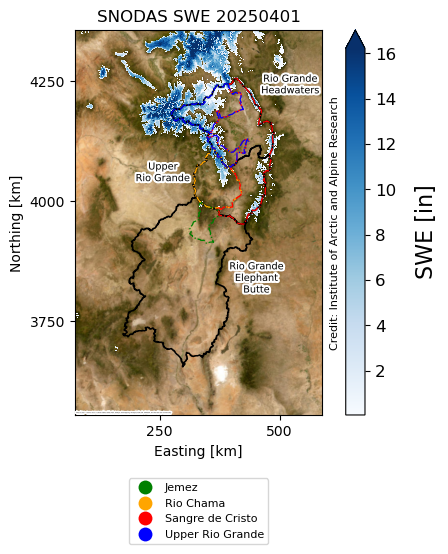

In [38]:
bounds = huc6.total_bounds
xpad = 100000
ypad = 100000
bounds_padded = [bounds[0]-xpad, bounds[1]-ypad, bounds[2]+xpad, bounds[3]+ypad]
clipped_data = snodas_utm.where(snodas_utm>=0).rio.clip_box(*bounds_padded) / 1000 * 3.2808 * 12 # convert to inches
clipped_data = clipped_data.where(clipped_data != 0, np.nan)

## percentile for colorbar
perc_max = np.nanpercentile(clipped_data, 95)
#clipped_data = clipped_data.where(clipped_data <= perc_max)

## manually assign OSE colors
custom_colors = ["green", "orange", "red", "blue"]
custom_cmap = mcolors.ListedColormap(custom_colors)

# Plot
fig, ax = plt.subplots(figsize=(6,5))
clipped_data.plot(ax=ax, cmap='Blues', vmax = perc_max)
#clipped_data.plot(ax=ax, cmap='Blues')
cbar = ax.collections[-1].colorbar
cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)

# source = cx.providers.CartoDB.Positron
#source = cx.providers.Esri.WorldImagery
cx.add_basemap(ax, crs=clipped_data.rio.crs, source = cx.providers.Esri.WorldImagery, 
               attribution_size=0)
#cx.add_basemap(ax, crs=clipped_data.rio.crs)
#plt.colorbar(label='SWE (mm)')
huc6.plot(color='None',
                    edgecolor='black',
                    linewidth=1.1,
                    ax=ax)

## add polygon labels
dx = [125000, -145000, 150000]
dy = [80000, 25000, 0]
label_text = ['Rio Grande\nHeadwaters', 'Upper\nRio Grande', 
              'Rio Grande\nElephant\nButte']
for idx, row in huc6.iterrows():
    #label_text = row["Name"].replace(" ", "\n")

    centroid = row.geometry.centroid
    print(centroid)
    ax.text(centroid.x + dx[idx], centroid.y + dy[idx], label_text[idx], #row["Name"],
            fontsize=7, color="black", ha="center", va="center",
            path_effects=[PathEffects.withStroke(linewidth=3, foreground="white")])
    print(dx[idx], dy[idx])
    print(row['Name'])

## plot with outlined polygons
## dotted lines so overlapping boundaries are visible

OSE.plot(column='SubBasin',  
         #cmap='turbo',
         cmap = custom_cmap,
         facecolor='none', 
         edgecolor=None, 
         linewidth=0.9,  
         legend=True,
         legend_kwds={'fontsize': 8},
         ax=ax,
         alpha=1,
         linestyle="-.")
         

m2km = lambda x, _: f'{x/1000:g}'
ax.xaxis.set_major_formatter(m2km)
ax.yaxis.set_major_formatter(m2km)
ax.locator_params(axis="x", nbins=2)
ax.locator_params(axis="y", nbins=4)
#ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
ax.set_xlabel('Easting [km]')
ax.set_ylabel('Northing [km]')
ax.set_title('SNODAS SWE ' + date)

ax.text(1.05, 0.5, 'Credit: Institute of Arctic and Alpine Research', rotation=90, 
        va='center', ha='center', transform=ax.transAxes, fontsize=8)

legend = ax.get_legend()
if legend:
    legend.set_bbox_to_anchor((0.5, -0.25)) # move legend below plot
    legend.set_loc("center")

plt.show()

## HUC6 Basin Figures

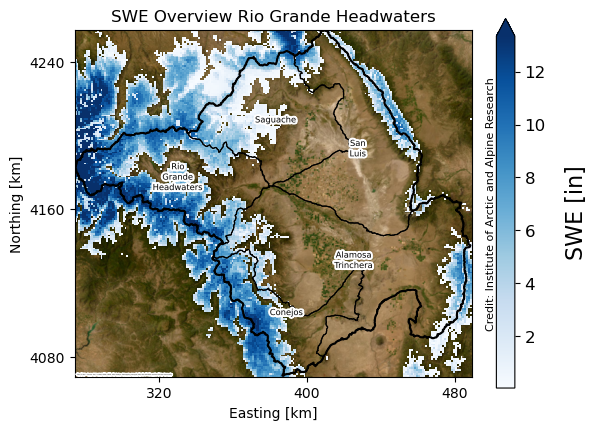

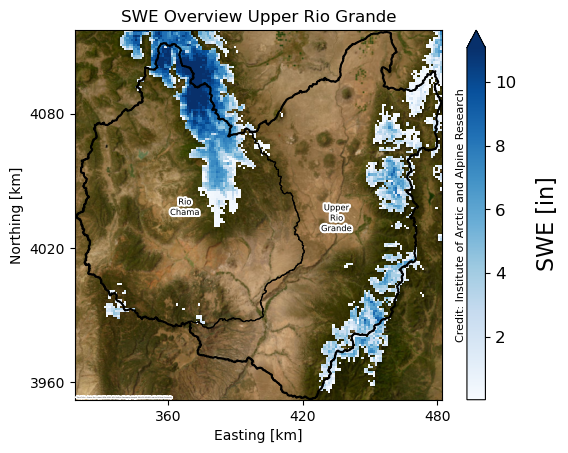

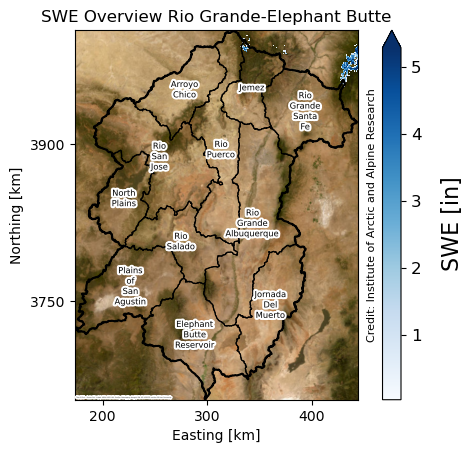

In [39]:
for idx, basin in huc6.iterrows():
    bounds = basin.geometry.bounds
    swe_basin = clipped_data.where(clipped_data>=0).rio.clip_box(*bounds)
    ## percentile for colorbar
    perc_max = np.nanpercentile(swe_basin, 95)
    #swe_basin = swe_basin.where(swe_basin <= perc_max) 

    huc8_basins = huc8.loc[huc8['HUC6 Basin'] == basin['Name']]
    #print(huc8_basins)

    #swe_basin = clipped_data.rio.clip([basin.geometry])
        
    ## plot clipped polygon
    f, ax = plt.subplots()
    #swe_basin.plot(cmap="Blues", ax=ax)
    swe_basin.plot(ax=ax, cmap='Blues', vmax = perc_max)
    cbar = ax.collections[-1].colorbar
    cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
    cbar.ax.tick_params(labelsize=12)

    cx.add_basemap(ax, crs=clipped_data.rio.crs, source = cx.providers.Esri.WorldImagery, attribution_size=0)
    #cx.add_basemap(ax, crs=clipped_data.rio.crs)

    gpd.GeoSeries(basin.geometry).boundary.plot(ax=ax, edgecolor="black", linewidth=1.5)
    huc8_basins.plot(color='None',
                    edgecolor='black',
                    linewidth=0.8,
                    ax=ax)
    ## add huc8 polygon labels
    
    for idx, row in huc8_basins.iterrows():
        label_text = row["Name"].replace("-", " ")
        label_text = label_text.replace(" ", "\n")

        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, label_text, #row["Name"],
                fontsize=6, color="black", ha="center", va="center",
                path_effects=[PathEffects.withStroke(linewidth=3, foreground="white")])
                

    m2km = lambda x, _: f'{x/1000:g}'
    ax.xaxis.set_major_formatter(m2km)
    ax.yaxis.set_major_formatter(m2km)
    #ax.locator_params(axis="x", nbins=3)
    #ax.locator_params(axis="y", nbins=3)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(3))
    plt.gca().yaxis.set_major_locator(plt.MaxNLocator(3))
    #ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
    ax.set_xlabel('Easting [km]')
    ax.set_ylabel('Northing [km]')
    ax.set_title('SWE Overview ' + basin['Name'])
    ax.text(1.05, 0.5, 'Credit: Institute of Arctic and Alpine Research', rotation=90, 
            va='center', ha='center', transform=ax.transAxes, fontsize=8)
    plt.show()

## Difference Plot

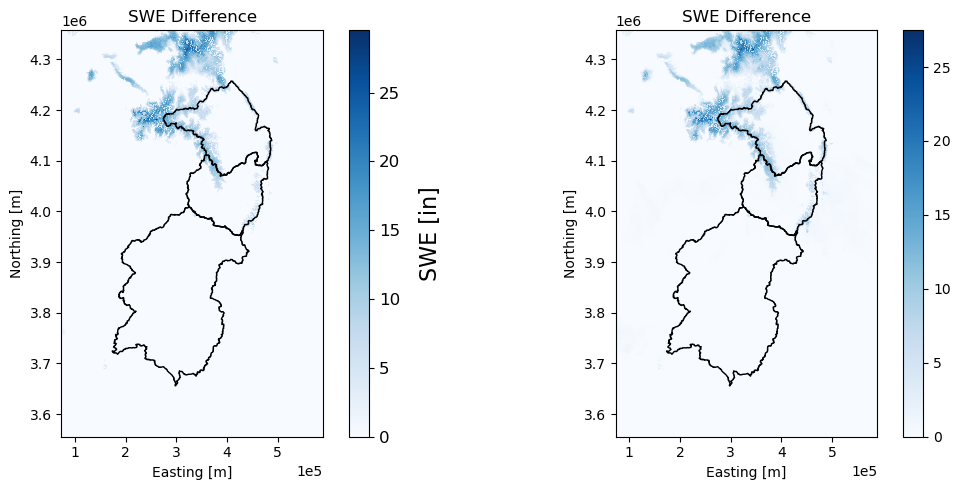

In [31]:
# Read data, reproject to UTM Zone 13N
snodas_new = rxr.open_rasterio('../data/SNODAS/SNODAS_SWE_20250325.tif').sel(band=1).reset_coords('band', drop=True)
snodas_utm_new = snodas_new.rio.reproject('epsg:26913', resolution=1000, resampling = 0) # 0=nearest neighbor
clipped_data_new = snodas_utm_new.where(snodas_utm_new>=0).rio.clip_box(*bounds_padded) / 1000 * 3.2808 * 12 # convert to inches

snodas_old = rxr.open_rasterio('../data/SNODAS/SNODAS_SWE_20250310.tif').sel(band=1).reset_coords('band', drop=True)
snodas_utm_old = snodas_old.rio.reproject('epsg:26913', resolution=1000, resampling = 0) # 0=nearest neighbor
clipped_data_old = snodas_utm_old.where(snodas_utm_old>=0).rio.clip_box(*bounds_padded) / 1000 * 3.2808 * 12 # convert to inches

fig, ax = plt.subplots(1, 2, figsize=(11,5))
clipped_data_new.plot(ax=ax[0], cmap='Blues')
clipped_data_old.plot(ax=ax[1], cmap='Blues')
cbar = ax[0].collections[-1].colorbar
cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)
#huc8.plot(ax=ax[0], facecolor='none', edgecolor='k')
huc6.plot(ax=ax[0], facecolor='none', edgecolor = 'black')
#huc8.plot(ax=ax[0], facecolor='none', edgecolor='k')
huc6.plot(ax=ax[1], facecolor='none', edgecolor = 'black')
#huc6_viz.plot(ax=ax[0], facecolor='none', edgecolor='k')
#huc6_viz.plot(ax=ax[1], facecolor='none', edgecolor='k')
for axx in ax.flatten():
    axx.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
    axx.set_xlabel('Easting [m]')
    axx.set_ylabel('Northing [m]')
    axx.set_title('SWE Difference')
plt.tight_layout()

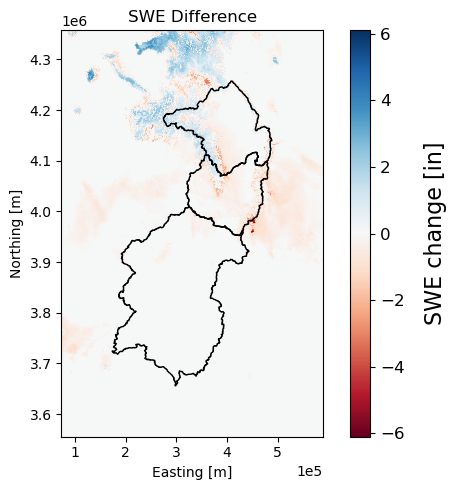

In [32]:
swe_diff = clipped_data_new - clipped_data_old
swe_diff.where(swe_diff != 0, np.nan)

# Plot
fig, ax = plt.subplots(figsize=(6,5))
swe_diff.plot(ax=ax, cmap='RdBu')
cbar = ax.collections[-1].colorbar
cbar.set_label('SWE change [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)
#huc8.plot(ax=ax, facecolor='none', edgecolor='k')
huc6.plot(ax=ax, facecolor='none', edgecolor = 'black')
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_title('SWE Difference')
plt.tight_layout()

In [26]:
np.nanmin(swe_diff)

0.0